# 📈 **Linear Regression**

**In Machine Learning and this notebook we use Scikit-learn a lot.**

<a href="https://uupload.ir/" target="_blank"><img src="https://s4.uupload.ir/files/download_(1)_slz6.png" border="0" alt="آپلود عکس" /></a>

### **What is scikit-learn used for?**

Scikit-learn (Sklearn) is the most useful and robust library for machine learning in Python. It provides a selection of efficient tools for machine learning and statistical modeling including classification, regression, clustering and dimensionality reduction via a consistence interface in Python.

#### **What is linear regression used for?**

Linear regression analysis is used to predict the value of a variable based on the value of another variable. The variable you want to predict is called the dependent variable. The variable you are using to predict the other variable's value is called the independent variable.

# **Making Predictions with Linear Regression**

Given the representation is a linear equation, making predictions is as simple as solving the equation for a specific set of inputs.

Let’s make this concrete with an example. Imagine we are predicting weight (y) from height (x). Our linear regression model representation for this problem would be:

**y = B0 + B1 * x1**

or

**weight =B0 +B1 * height**

Where B0 is the bias coefficient and B1 is the coefficient for the height column. We use a learning technique to find a good set of coefficient values. Once found, we can plug in different height values to predict the weight.

For example, lets use B0 = 0.1 and B1 = 0.5. Let’s plug them in and calculate the weight (in kilograms) for a person with the height of 182 centimeters.

weight = 0.1 + 0.5 * 182

weight = 91.1

You can see that the above equation could be plotted as a line in two-dimensions. The B0 is our starting point regardless of what height we have. We can run through a bunch of heights from 100 to 250 centimeters and plug them to the equation and get weight values, creating our line.

<a href="https://uupload.ir/" target="_blank"><img src="https://s4.uupload.ir/files/sample-height-vs-weight-linear-regression_10h7.png" border="0" alt="آپلود عکس" /></a>

Now that we know how to make predictions given a learned linear regression model, let’s look at some rules of thumb for preparing our data to make the most of this type of model.

# 📤 Import & Install Libraries

In [1]:
# !pip install hvplot

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

from sklearn.model_selection import train_test_split

from sklearn import metrics

from sklearn.linear_model import LinearRegression

%matplotlib inline

## 💾 Check out the Data

In [3]:
df=pd.read_csv('./Real estate.csv')

In [4]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
print(df.shape)

(414, 8)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [7]:
df.corr()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,1.000000,-0.048658,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
X1 transaction date,-0.048658,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
X2 house age,-0.032808,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,-0.012699,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,-0.010110,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.011059,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,-0.028587,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


<Axes: >

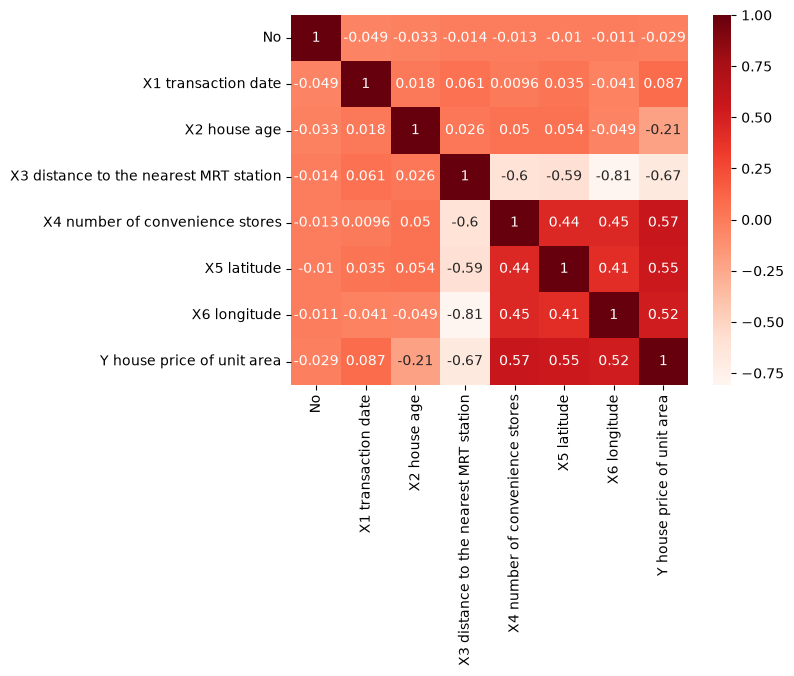

In [8]:
sns.heatmap(df.corr(), annot=True,cmap='Reds')

# 📊 Exploratory Data Analysis (EDA)

In [9]:
# sns.pairplot(df)

# 📈 Training a Linear Regression Model

## X and y arrays

In [10]:
# X=df.drop('Y house price of unit area', axis=1)

# y=df['X4 number of convenience stores']


X = df.drop(columns=['Y house price of unit area', 'No', "X1 transaction date", "X2 house age"])

y = df['Y house price of unit area']

In [11]:
print("X=",X.shape,"\ny=", y.shape)

X= (414, 4) 
y= (414,)


## 🧱 Train Test Split

Now let's split the data into a training set and a testing set. We will train out model on the training set and then use the test set to evaluate the model.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [13]:
X_train.shape

(289, 4)

In [14]:
X_test.shape

(125, 4)

# ✔️ Linear Regression

In [15]:
model = LinearRegression()

In [16]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ -0. , 1.18,235.91, 47.16]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['X3 distance to the nearest MRT station', 'X4 number of convenience stores','X5 latitude','X6 longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.158e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


## ✔️ Model Evaluation

In [17]:
model.coef_

array([-4.13410211e-03,  1.17953550e+00,  2.35911752e+02,  4.71579161e+01])

In [18]:
pd.DataFrame(model.coef_, X.columns, columns=['Coefficients'])

,Coefficients
X3 distance to the nearest MRT station,-0.004134
X4 number of convenience stores,1.179535
X5 latitude,235.911752
X6 longitude,47.157916


## ✔️ Predictions from our Model

In [19]:
y_pred = model.predict(X_test)

## ✔️ Regression Evaluation Metrics


Here are three common evaluation metrics for regression problems:

> - **Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:
$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

> - **Mean Squared Error** (MSE) is the mean of the squared errors:
$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

> - **Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:
$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

> 📌 Comparing these metrics:
- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

> All of these are **loss functions**, because we want to minimize them.

In [20]:
MAE= metrics.mean_absolute_error(y_test, y_pred)
MSE=metrics.mean_squared_error(y_test, y_pred)
RMSE= np.sqrt(MSE)

In [21]:
MAE

6.092476998635309

In [22]:
MSE

57.1719352844051

In [23]:
RMSE

np.float64(7.561212553843801)

In [24]:
df['X4 number of convenience stores'].mean()

np.float64(4.094202898550725)

## **Residual Histogram**

* **Often for Linear Regression it is a good idea to separately evaluate residuals $$(y-\hat{y})$$ and not just calculate performance metrics (e.g. RMSE).**

* **Let's explore why this is important...**

* **The residual eerors should be random and close to a normal distribution.**


<a href="https://uupload.ir/" target="_blank"><img src="https://s4.uupload.ir/files/download_ycg.png" border="0" alt="آپلود عکس" /></a>

<a href="https://uupload.ir/" target="_blank"><img src="https://s4.uupload.ir/files/2_pe68.png" border="0" alt="آپلود عکس" /></a>

In [25]:
test_residual= y_test - y_pred


print(test_residual)

176     6.585609
347     4.325558
307     1.153119
299    -6.672654
391     3.164413
         ...    
16     23.589240
31    -21.492475
36     -7.485957
41      4.439754
24     -3.383089
Name: Y house price of unit area, Length: 125, dtype: float64


In [26]:
pd.DataFrame({'Error Values': (test_residual)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

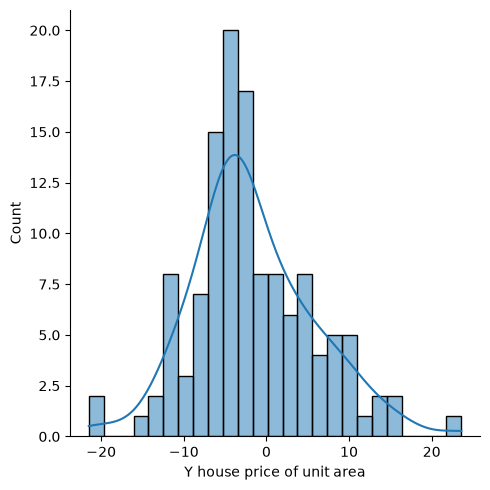

In [27]:
sns.displot(test_residual, bins=25, kde=True)

* **Residual plot shows residual error VS. true y value.**

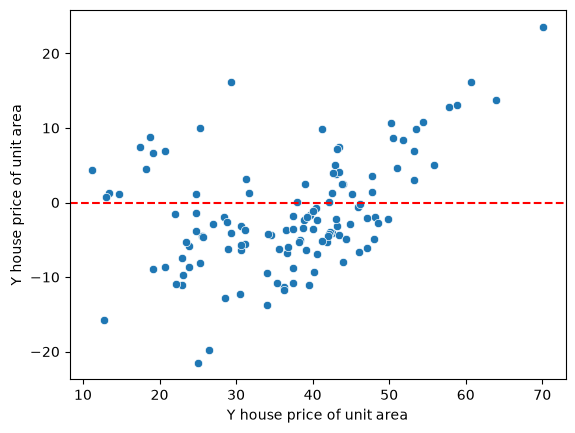

In [28]:
sns.scatterplot(x=y_test, y=test_residual)

plt.axhline(y=0, color='r', ls='--')

* **Residualplot showing a clear pattern, indicating Linear Regression no valid!**

# Finished, but you can copy this notebook and start practicing.